# 🚢 Titanic Survival Analysis

## Project Purpose

This project analyzes the Titanic dataset to understand the factors that affected passenger survival.

## Dataset Description

The dataset contains information about Titanic passengers, such as age, gender, passenger class, fare, and survival status. The analysis will be used to identify patterns and relationships between these features and passenger survival.

## Libraries Used

* **Pandas** – Data loading, cleaning, and analysis
* **NumPy** – Numerical operations
* **Matplotlib** – Data visualization
* **Seaborn** – Statistical data visualization


## 1. Import Libraries
We use Pandas and NumPy for data analysis and Matplotlib and Seaborn for visualization.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [4]:
data1=pd.read_csv('train.csv')
df=pd.DataFrame(data1)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


## 3. Initial Data Inspection

In [38]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (891, 14)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup', 'FamilySize']


## 4. Dataset Information

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 5. Statistical Summary

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 6. Check Missing Values

In [10]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## 7. Handle Missing Values
- Age → median
- Embarked → mode
- Cabin → `"Unknown"`

In [11]:
df['Age']=pd.to_numeric(df['Age'], errors='coerce')
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Age']=df['Age'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(1), int64(6), str(5)
memory usage: 83.7 KB


In [12]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C148,C


In [13]:
df['Cabin']=df['Cabin'].fillna('Unknown')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,Unknown,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,Unknown,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C148,C


In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## 8. Check and Remove Duplicate Rows

In [15]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


## 9. Check Data Types

In [16]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age              int64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## 📊 10 Survival Analysis
`0 = Did Not Survive`, `1 = Survived`

In [17]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [18]:
survival_rate=df['Survived'].mean()*100
print("Survival Rate:", round(survival_rate, 2), "%")

Survival Rate: 38.38 %


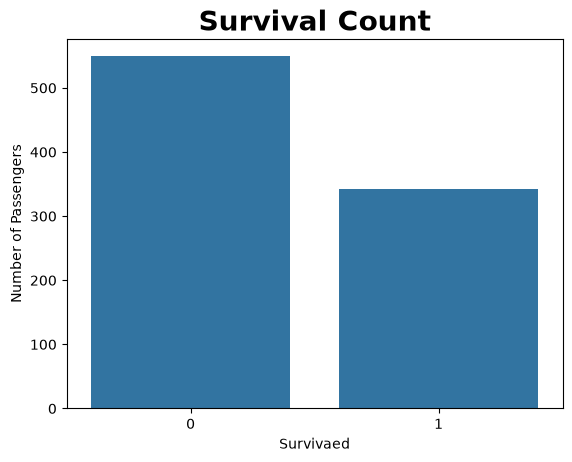

In [19]:
sns.countplot(x='Survived',data=df)

plt.title('Survival Count',fontweight='bold',fontsize=20)
plt.xlabel('Survivaed')
plt.ylabel('Number of Passengers')
plt.show() 

## 11 Survival by Gender


In [20]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

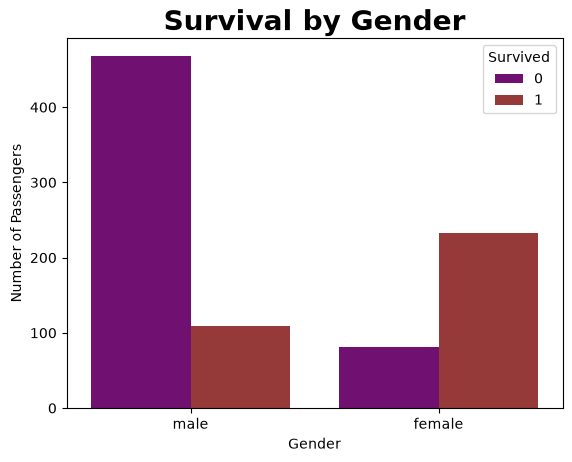

In [21]:
sns.countplot(x='Sex',hue='Survived',data=df,palette=['purple','brown'])
plt.title('Survival by Gender',fontweight='bold',fontsize=20)
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

## 12 Passenger-Class Survival Analysis

In [22]:
class_survival_rate = df.groupby('Pclass')['Survived'].mean() * 100
class_survival_rate.round(2)

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

## 13 Age Analysis

In [23]:
df['Age'].agg(["count","mean","median","min","max"])

count     891.000000
mean       29.544332
median     29.000000
min         0.000000
max        80.000000
Name: Age, dtype: float64

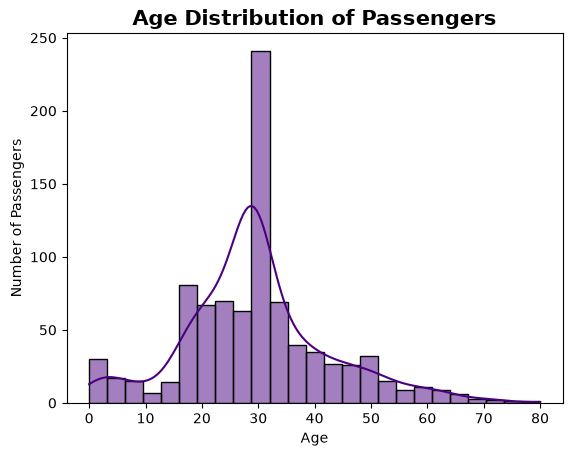

In [24]:
sns.histplot(df['Age'], bins=25, kde=True, color='#4B0082')
plt.title('Age Distribution of Passengers',fontweight='bold',fontsize=15)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## 14. Age vs Survival — LinePlot

In [25]:
bins = [0, 12, 19, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup']=pd.cut(df['Age'],bins=bins,labels=labels)
age_survival = df.groupby('AgeGroup')['Survived'].mean()*100
age_survival.round(2)

AgeGroup
Child     53.23
Teen      41.05
Adult     36.52
Senior    26.92
Name: Survived, dtype: float64

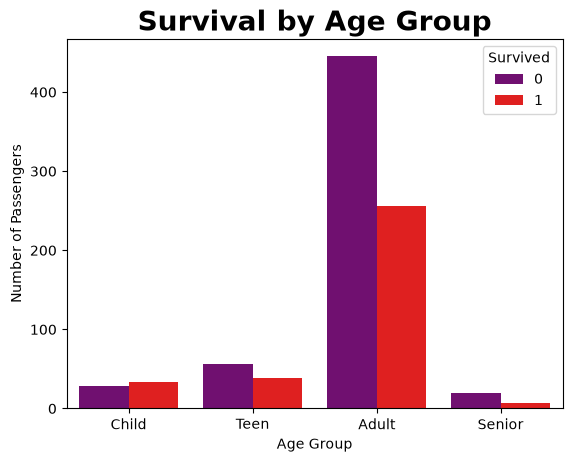

In [26]:
sns.countplot(x='AgeGroup',hue='Survived',data=df,palette=['purple','red'])
plt.title('Survival by Age Group',fontweight='bold',fontsize=20)
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.show()

## 15. Fare Statistics and Survival Comparison

In [27]:
display(df["Fare"].agg(["count", "mean", "median", "min", "max"]).to_frame("Fare"))
fare_by_survival = df.groupby("Survived")["Fare"].agg(["mean", "median", "min", "max"])
fare_by_survival.index = ["Did Not Survive", "Survived"]
fare_by_survival

,Fare
count,891.000000
mean,32.204208
median,14.454200
min,0.000000
max,512.329200


,mean,median,min,max
Did Not Survive,22.117887,10.5,0.0,263.0000
Survived,48.395408,26.0,0.0,512.3292


## 16. Fare vs Survival — Box Plot

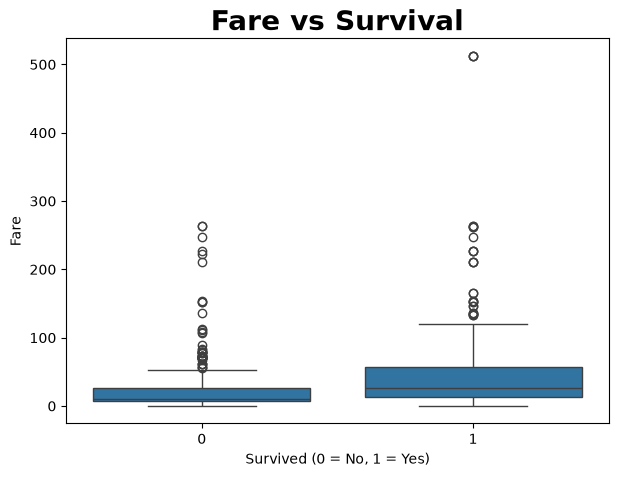

In [28]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Survived',y='Fare',data=df,legend=False)
plt.title('Fare vs Survival',fontweight='bold',fontsize=20)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

## 17. Family Size vs Survival

In [29]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
family_analysis = df.groupby("FamilySize")["Survived"].agg(
    Total_Passengers="count",
    Survivors="sum",
    Survival_Rate="mean"
)
family_analysis["Survival_Rate"] *= 100
family_analysis

,Total_Passengers,Survivors,Survival_Rate
FamilySize,,,
1,537,163,30.353818
2,161,89,55.279503
3,102,59,57.843137
4,29,21,72.413793
5,15,3,20.000000
6,22,3,13.636364
7,12,4,33.333333
8,6,0,0.000000
11,7,0,0.000000


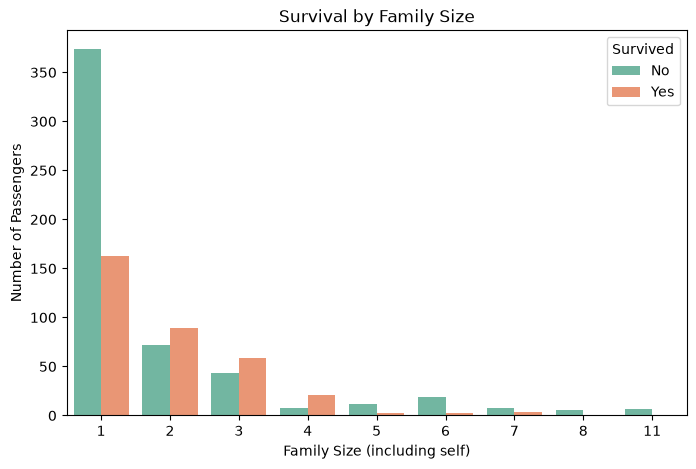

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x='FamilySize', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Family Size')
plt.xlabel('Family Size (including self)')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# 18 Correlation Analysis

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
correlation_matrix 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
PassengerId,1.000000,-0.005007,-0.035144,0.033741,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.067809,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.335071,0.083081,0.018443,-0.549500,0.065997
Age,0.033741,-0.067809,-0.335071,1.000000,-0.232743,-0.176744,0.093856,-0.247370
SibSp,-0.057527,-0.035322,0.083081,-0.232743,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.176744,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.093856,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.247370,0.890712,0.783111,0.217138,1.000000


## 19. Survival by Port of Embarkation & Title

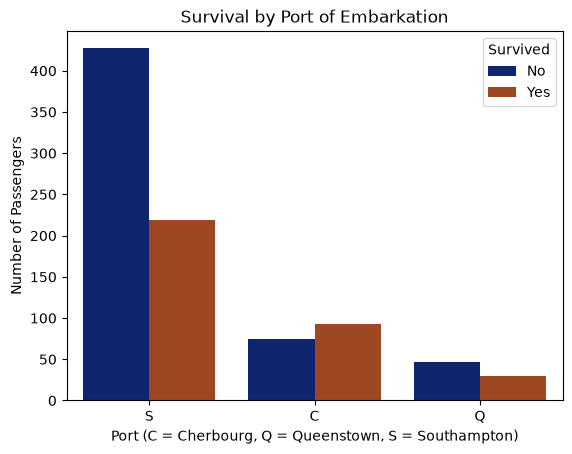

In [32]:
sns.countplot(x='Embarked', hue='Survived', data=df, palette='dark')
plt.title('Survival by Port of Embarkation')
plt.xlabel('Port (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

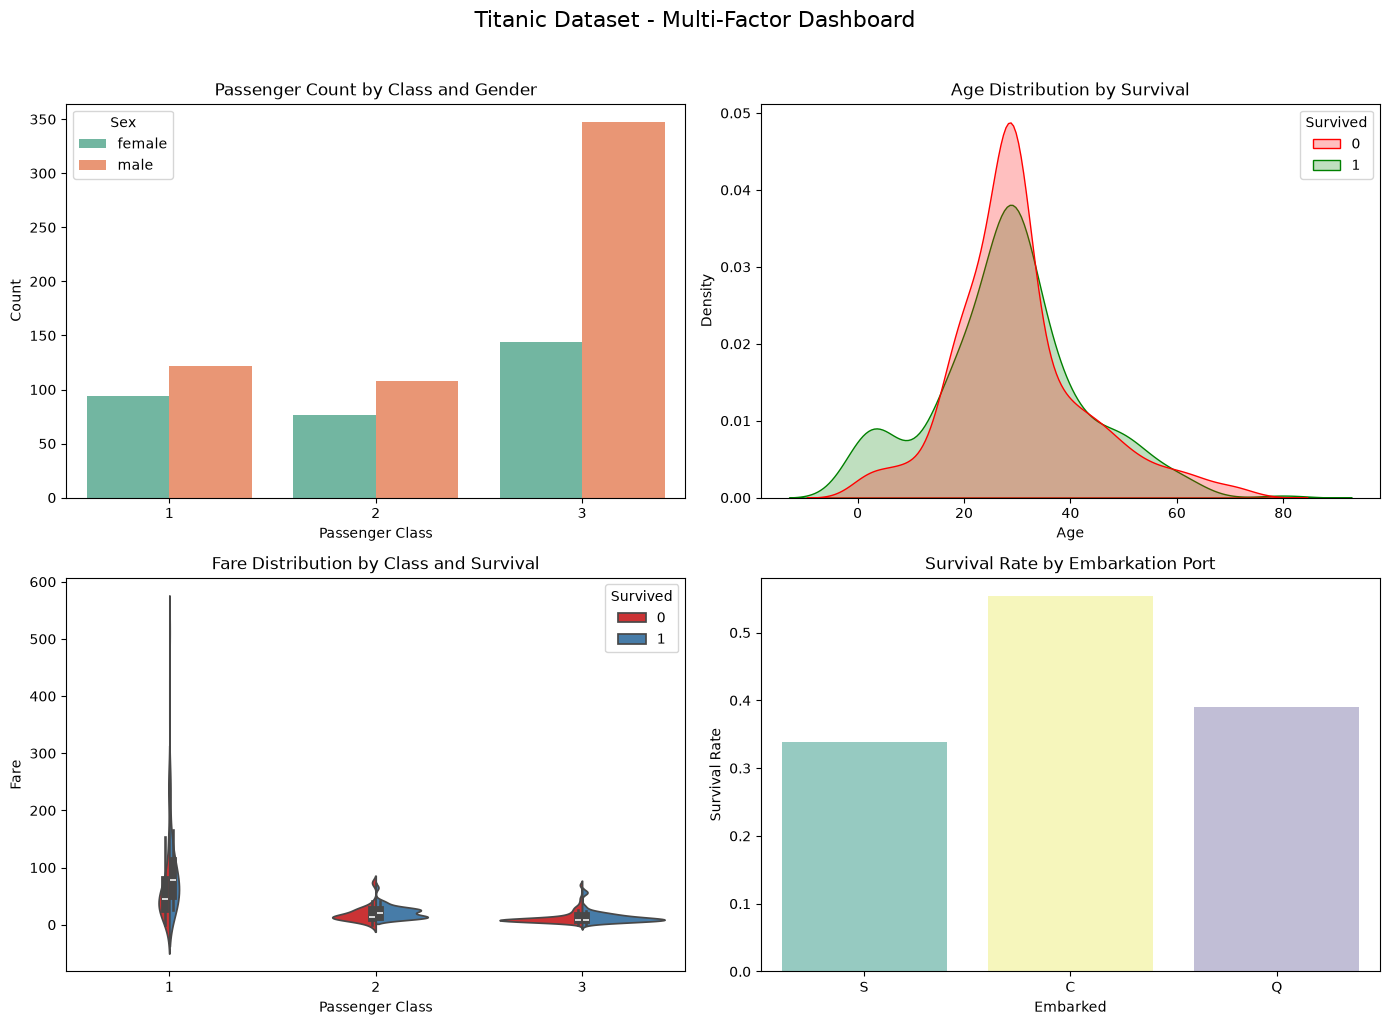

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Passenger count by class and gender
sns.countplot(x='Pclass', hue='Sex', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Passenger Count by Class and Gender')
axes[0,0].set_xlabel('Passenger Class')
axes[0,0].set_ylabel('Count')

# Top-right: Age distribution by survival (KDE)
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False, ax=axes[0,1], palette=['red','green'])
axes[0,1].set_title('Age Distribution by Survival')
axes[0,1].set_xlabel('Age')

# Bottom-left: Fare distribution by class and survival (split violin)
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=df, split=True, ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Fare Distribution by Class and Survival')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Fare')

# Bottom-right: Survival rate by embarkation port
sns.barplot(x='Embarked', y='Survived', hue='Embarked', data=df, ax=axes[1,1], palette='Set3', errorbar=None, legend=False)
axes[1,1].set_title('Survival Rate by Embarkation Port')
axes[1,1].set_xlabel('Embarked')
axes[1,1].set_ylabel('Survival Rate')

plt.suptitle('Titanic Dataset - Multi-Factor Dashboard', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

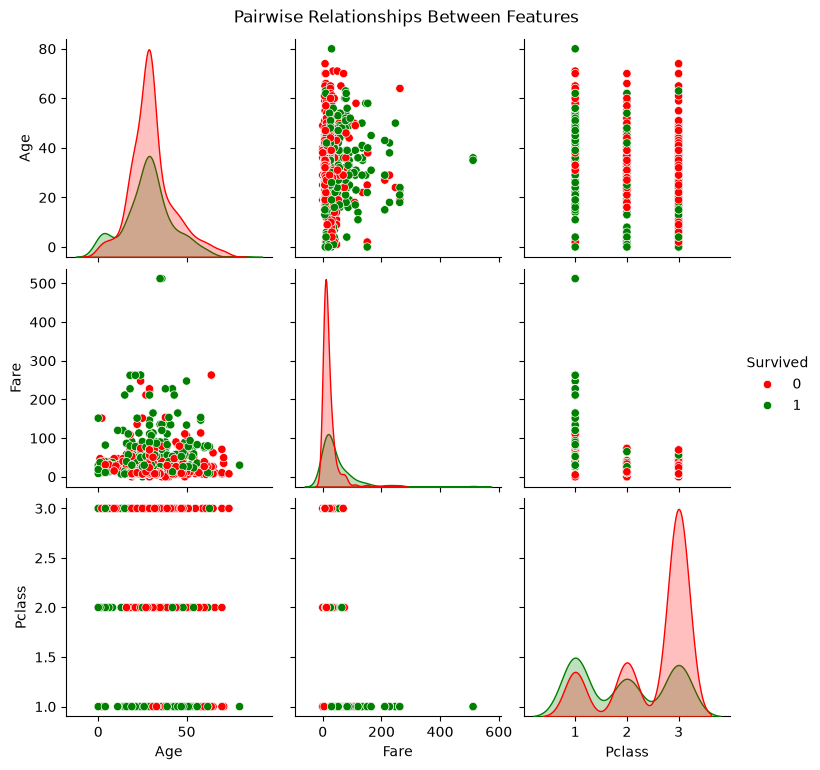

In [34]:
g = sns.pairplot(df[['Survived','Age','Fare','Pclass']], hue='Survived', palette=['red','green'], diag_kind='kde')
g.fig.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

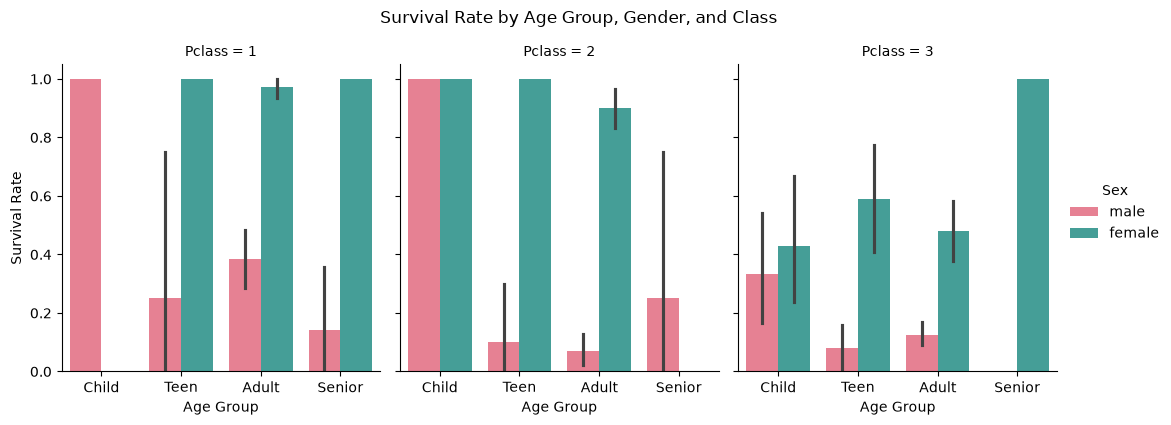

In [35]:
g3 = sns.catplot(x='AgeGroup', y='Survived', hue='Sex', col='Pclass', data=df, kind='bar', height=4, aspect=0.9, palette='husl')
g3.fig.suptitle('Survival Rate by Age Group, Gender, and Class', y=1.05)
g3.set_axis_labels('Age Group', 'Survival Rate')
plt.show()

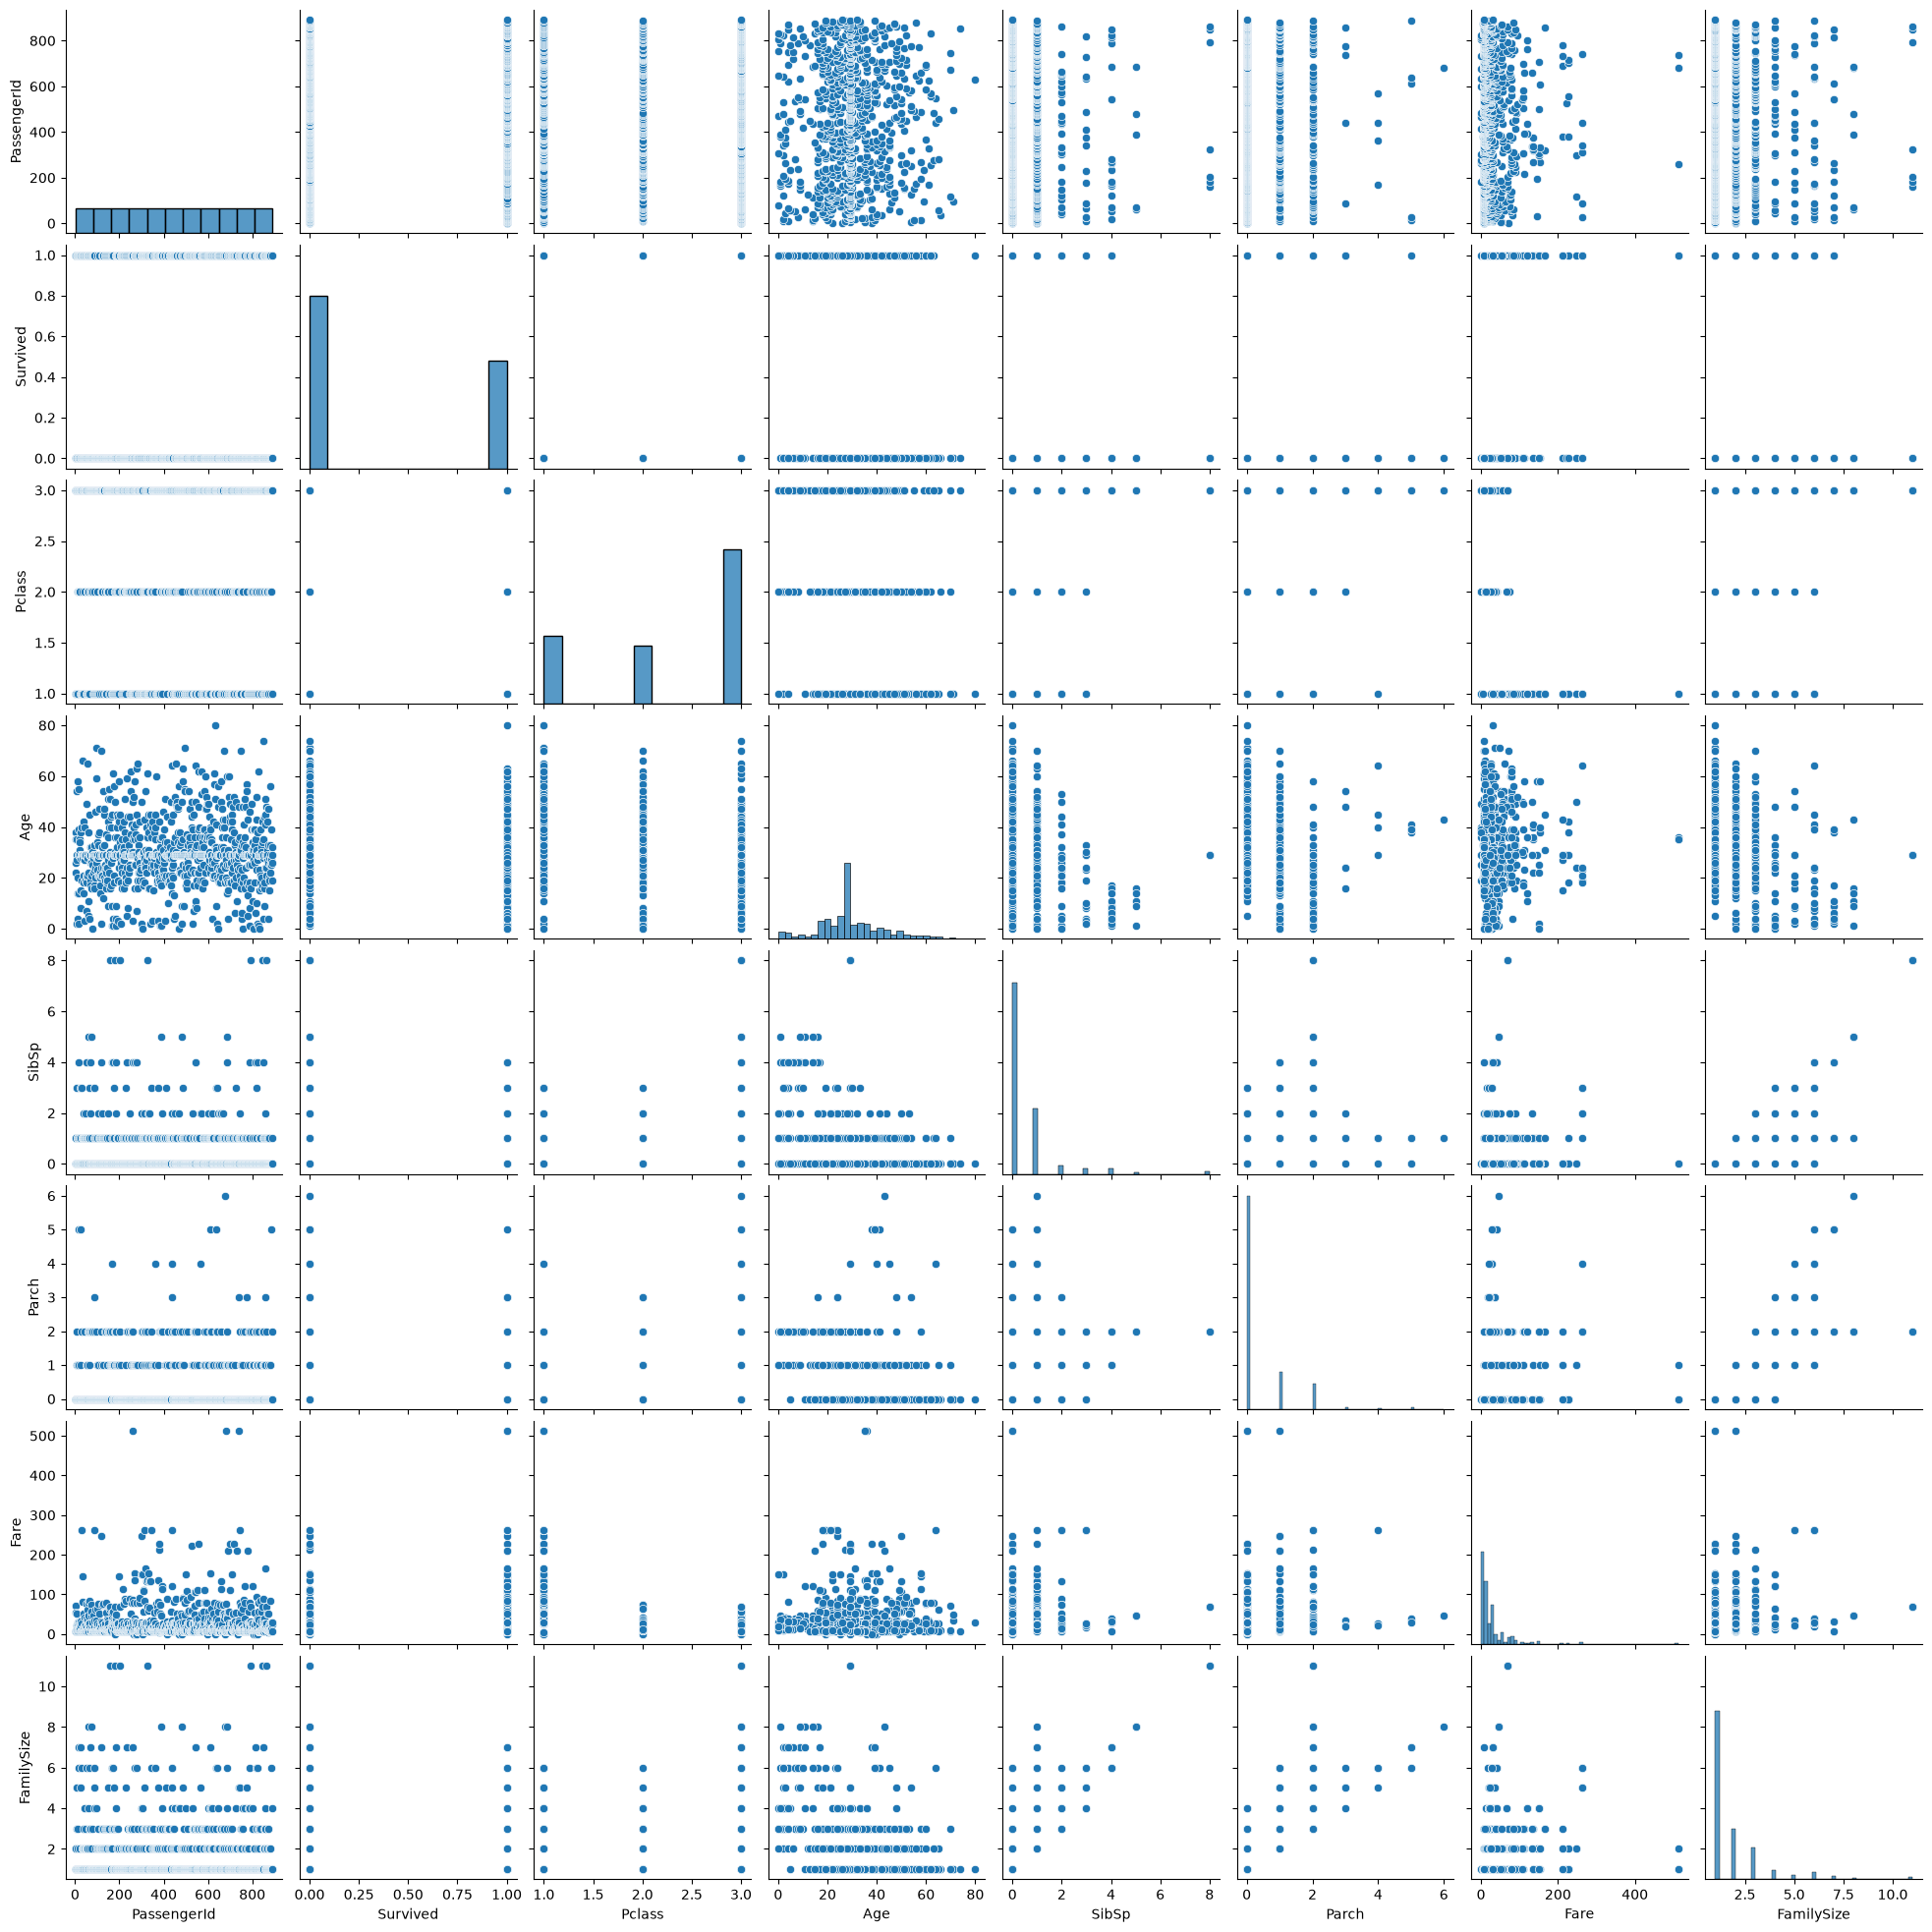

In [36]:
sns.pairplot(df)

## 20. Correlation Heatmap

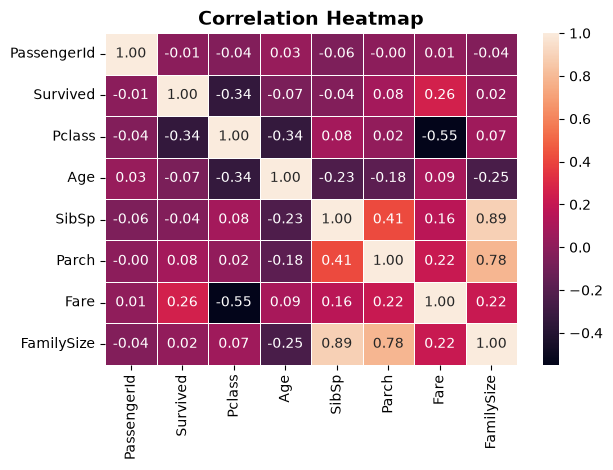

In [37]:
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ✅ Final Conclusion

The Titanic dataset shows that passenger survival was associated with several characteristics, especially **gender and passenger class**. Age, fare, and family size also provided useful patterns during the exploratory analysis.

This project demonstrates a complete **Exploratory Data Analysis (EDA)** workflow using Python, Pandas, Matplotlib, and Seaborn, including data inspection, cleaning, statistical analysis, visualization, and interpretation.